<a href="https://colab.research.google.com/github/kshamie3505-a11y/Codveda-Internship-Tasks/blob/main/Level3Task1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
df = pd.read_csv('/content/FOE.csv')
df

,Date,Open,High,Low,Close,Adj Close,Volume
0,1980-03-17,0.000000,2.722222,2.685185,2.685185,1.450476,47925
1,1980-03-18,0.000000,2.703704,2.666667,2.685185,1.450476,77625
2,1980-03-19,0.000000,2.703704,2.666667,2.703704,1.460480,35775
3,1980-03-20,0.000000,2.777778,2.703704,2.722222,1.470483,42525
4,1980-03-21,0.000000,2.777778,2.740741,2.740741,1.480487,37125
...,...,...,...,...,...,...,...
10585,2022-03-09,21.639999,21.780001,21.450001,21.780001,21.780001,820400
10586,2022-03-10,21.570000,21.799999,21.559999,21.790001,21.790001,409500
10587,2022-03-11,21.750000,21.790001,21.660000,21.780001,21.780001,538200
10588,2022-03-14,21.780001,21.780001,21.730000,21.750000,21.750000,726700


In [2]:
df.info

<bound method DataFrame.info of              Date       Open       High        Low      Close  Adj Close  \
0      1980-03-17   0.000000   2.722222   2.685185   2.685185   1.450476   
1      1980-03-18   0.000000   2.703704   2.666667   2.685185   1.450476   
2      1980-03-19   0.000000   2.703704   2.666667   2.703704   1.460480   
3      1980-03-20   0.000000   2.777778   2.703704   2.722222   1.470483   
4      1980-03-21   0.000000   2.777778   2.740741   2.740741   1.480487   
...           ...        ...        ...        ...        ...        ...   
10585  2022-03-09  21.639999  21.780001  21.450001  21.780001  21.780001   
10586  2022-03-10  21.570000  21.799999  21.559999  21.790001  21.790001   
10587  2022-03-11  21.750000  21.790001  21.660000  21.780001  21.780001   
10588  2022-03-14  21.780001  21.780001  21.730000  21.750000  21.750000   
10589  2022-03-15  21.750000  21.760000  21.690001  21.700001  21.700001   

       Volume  
0       47925  
1       77625  
2       35775  
3       42525  
4       37125  
...       ...  
10585  820400  
10586  409500  
10587  538200  
10588  726700  
10589  555820  

[10590 rows x 7 columns]>

In [3]:
df.shape

(10590, 7)

In [4]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')

In [5]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,10590.000000,10590.000000,10590.000000,10590.000000,10590.000000,1.059000e+04
mean,13.607281,14.631222,14.240872,14.439353,11.952665,3.662785e+05
std,8.521814,7.381201,7.230212,7.309994,6.597625,6.056098e+05
min,0.000000,1.010000,0.810000,0.860000,0.860000,0.000000e+00
25%,7.072500,7.740000,7.420000,7.611111,5.995661,7.695000e+04
50%,14.860000,15.080000,14.666667,14.865000,12.818146,1.966500e+05
75%,20.610001,20.847500,20.333332,20.620001,17.534573,4.675750e+05
max,30.250000,30.937500,30.000000,30.549999,25.350000,2.044590e+07


In [6]:
df.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


**Plot and Decompose Time Series into trend, seasonality, and residual components. This will help in understanding the underlying patterns.**


**First step is to convert the 'Date' column to datetime objects and set it as the DataFrame's index. Crucial for time series analysis.**



In [7]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date')
print("Date column converted to datetime and set as index.")

Date column converted to datetime and set as index.


**Creating a time series specifically for the 'Close' prices and visualize it to understand its raw pattern.**



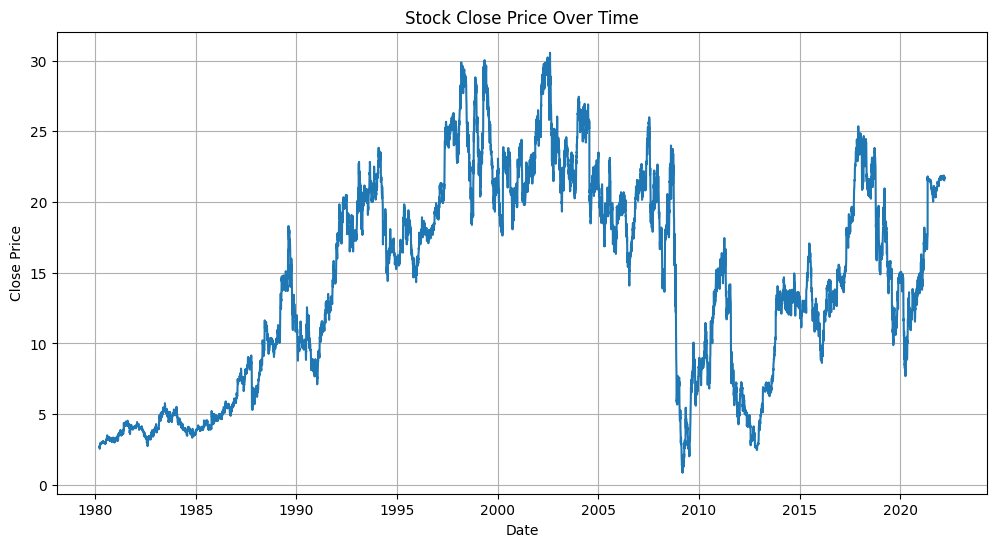

Time series data created and plotted.


In [8]:
import matplotlib.pyplot as plt

time_series_data = df['Close']

plt.figure(figsize=(12, 6))
plt.plot(time_series_data)
plt.title('Stock Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.grid(True)
plt.show()
print("Time series data created and plotted.")

**Decomposing the time series data created, using an appropriate period, and plotting the resulting components.**



<Figure size 1200x1000 with 0 Axes>

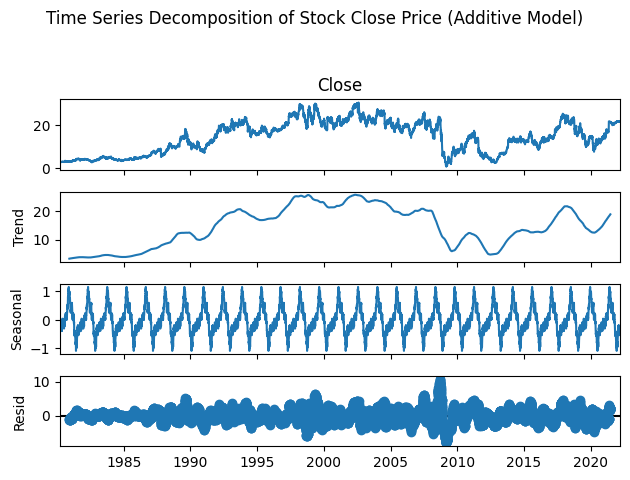

Time series decomposed into trend, seasonality, and residuals, and plots displayed.


In [9]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# Perform seasonal decomposition. Using a period of 365 for yearly seasonality.
# Model = additive first to see the general components.

# Using a yearly period of 365 because the dataset has many years of data.
decomposition = seasonal_decompose(time_series_data, model='additive', period=365)

# Plotting the decomposed components
plt.figure(figsize=(12, 10))
decomposition.plot()
plt.suptitle('Time Series Decomposition of Stock Close Price (Additive Model)', y=1.02) # Adjust suptitle position
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent overlap
plt.show()
print("Time series decomposed into trend, seasonality, and residuals, and plots displayed.")

**Applying Moving Average and Exponential Smoothing techniques to understand their effect on the time series.**

**First task** = calculating Simple Moving Average (SMA) and Exponential Moving Average (EMA) for the 'Close' price with a 30-day window and a 30-day span respectively, and adding them as new columns to the DataFrame.

In [10]:
df['SMA_30'] = df['Close'].rolling(window=30).mean()
df['EMA_30'] = df['Close'].ewm(span=30, adjust=False).mean() # Exponential weighted Moving/Moving Average
print("SMA_30 and EMA_30 calculated and added to the DataFrame.")

SMA_30 and EMA_30 calculated and added to the DataFrame.


**Visualizing the original 'Close' price along with the two smoothing techniques on a single chart. This will help in comparing their effects and understanding the smoothed trends.**

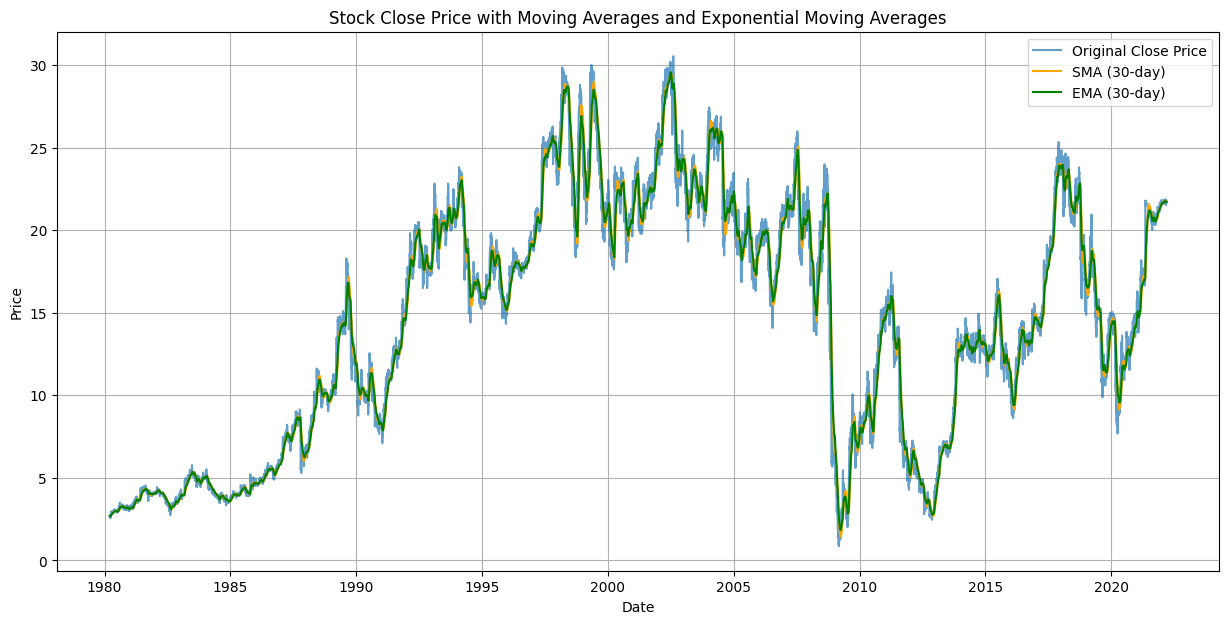

Plot of Close Price with SMA and EMA displayed.


In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 7))
plt.plot(df['Close'], label='Original Close Price', alpha=0.7)
plt.plot(df['SMA_30'], label='SMA (30-day)', color='orange')
plt.plot(df['EMA_30'], label='EMA (30-day)', color='green')
plt.title('Stock Close Price with Moving Averages and Exponential Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()
print("Plot of Close Price with SMA and EMA displayed.")

**Build ARIMA/SARIMA Model**
Develop an ARIMA (AutoRegressive Integrated Moving Average) or SARIMA (Seasonal ARIMA) model for forecasting.


**The first step = splitting the time series data into training and testing sets to evaluate the model's forecasting performance, using 80% as train data and 20% for testing.**



In [12]:
train_size = int(len(time_series_data) * 0.8)
train_data, test_data = time_series_data[0:train_size], time_series_data[train_size:]

print(f"Shape of training data: {train_data.shape}")
print(f"Shape of testing data: {test_data.shape}")

Shape of training data: (8472,)
Shape of testing data: (2118,)


**Ensure the time series is stationary.Performing the Augmented Dickey-Fuller (ADF) test to check for stationarity on the training data.**

In [13]:
from statsmodels.tsa.stattools import adfuller

def check_stationarity(timeseries): # Stationarity ensures a stable environment where models can learn consistent patterns hence robust and reliable forecasts
    # Perform Dickey-Fuller test:
    print('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
       dfoutput['Critical Value (%s)'%key] = value
    print(dfoutput)

    if dftest[1] <= 0.05:
        print("\nSeries is Stationary (p-value <= 0.05)")
    else:
        print("\nSeries is Non-Stationary (p-value > 0.05)")

print("Checking stationarity of the training data:")
check_stationarity(train_data)


Checking stationarity of the training data:
Results of Dickey-Fuller Test:
Test Statistic                   -2.360504
p-value                           0.153196
#Lags Used                       33.000000
Number of Observations Used    8438.000000
Critical Value (1%)              -3.431125
Critical Value (5%)              -2.861883
Critical Value (10%)             -2.566952
dtype: float64

Series is Non-Stationary (p-value > 0.05)


 **Applying differencing to make the time series stationary.** i.e. performing a first-order differencing on the train_data and then re-running the stationarity test to confirm its stationarity.



In [14]:
train_data_diff = train_data.diff().dropna()

print("Checking stationarity of the differenced training data:")
check_stationarity(train_data_diff)


Checking stationarity of the differenced training data:
Results of Dickey-Fuller Test:
Test Statistic                  -95.688674
p-value                           0.000000
#Lags Used                        0.000000
Number of Observations Used    8470.000000
Critical Value (1%)              -3.431122
Critical Value (5%)              -2.861881
Critical Value (10%)             -2.566952
dtype: float64

Series is Stationary (p-value <= 0.05)


**Determining the optimal orders for the AR (p) and MA (q) components of the ARIMA model** by examining the Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) plots of the differenced series. These plots will help identify the appropriate values for p and q.



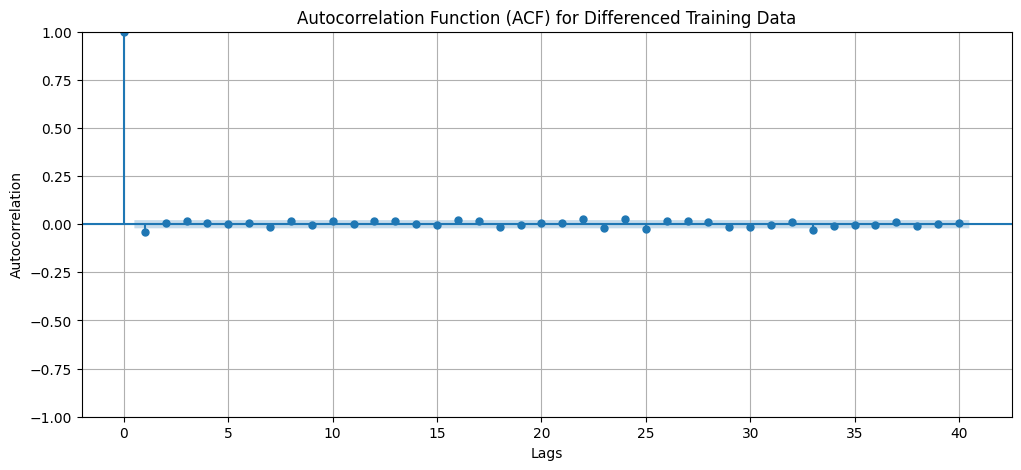

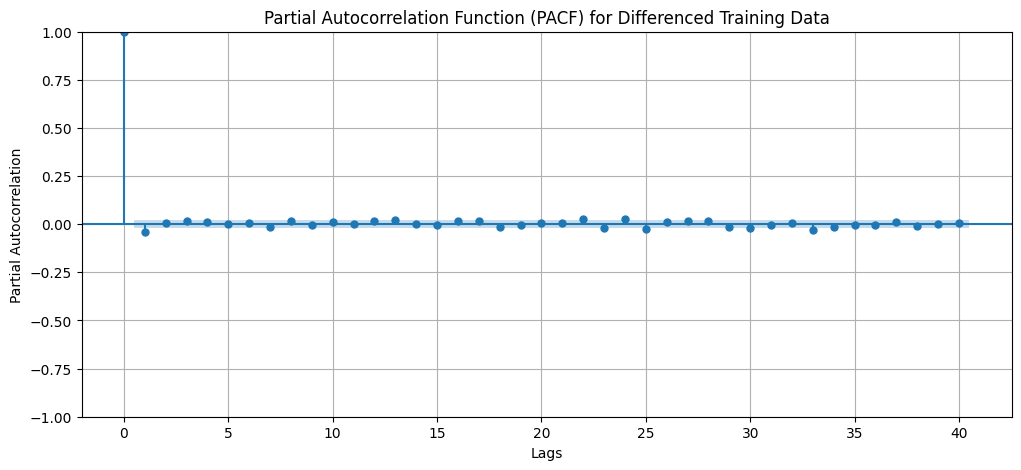

ACF and PACF plots for differenced training data displayed.


In [15]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Plot ACF
plt.figure(figsize=(12, 5))
plot_acf(train_data_diff, lags=40, ax=plt.gca())
plt.title('Autocorrelation Function (ACF) for Differenced Training Data')
plt.xlabel('Lags')
plt.ylabel('Autocorrelation')
plt.grid(True)
plt.show()

# Plot PACF
plt.figure(figsize=(12, 5))
plot_pacf(train_data_diff, lags=40, ax=plt.gca())
plt.title('Partial Autocorrelation Function (PACF) for Differenced Training Data')
plt.xlabel('Lags')
plt.ylabel('Partial Autocorrelation')
plt.grid(True)
plt.show()

print("ACF and PACF plots for differenced training data displayed.")


**With the differencing order (d=1) established and insights from the ACF and PACF plots for p and q, the next step is to fit an ARIMA model to the train_data.**

In [16]:
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings("ignore") # Ignore harmless warnings

# Based on ACF and PACF plots, let's try an ARIMA(1,1,1) model as a starting point.
# d = 1 (from differencing to achieve stationarity)
# p = 1 (PACF drops off after lag 1)
# q = 1 (ACF drops off after lag 1)

# Fit ARIMA model
model = ARIMA(train_data, order=(1, 1, 1))
model_fit = model.fit()

# Print model summary
print(model_fit.summary())
print("ARIMA model (1,1,1) fitted and summary displayed.")

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 8472
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -2823.026
Date:                Fri, 06 Mar 2026   AIC                           5652.051
Time:                        15:10:42   BIC                           5673.184
Sample:                             0   HQIC                          5659.264
                               - 8472                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1313      0.175     -0.750      0.453      -0.474       0.212
ma.L1          0.0923      0.176      0.525      0.600      -0.253       0.437
sigma2         0.1140      0.001    155.667      0.0

**Making predictions on the test set to evaluate its forecasting capability. Using the predict method of the fitted model to generate forecasts for the length of the test_data.**



In [17]:
start = len(train_data)
end = len(train_data) + len(test_data) - 1
predictions = model_fit.predict(start=start, end=end)

print("Predictions generated for the test set.")
print(f"Number of predictions: {len(predictions)}")


Predictions generated for the test set.
Number of predictions: 2118


**Evaluate the model's performance by comparing the predicted values with the actual values in the test set, using Mean Squared Error (MSE) and Root Mean Squared Error (RMSE).**



In [18]:
from sklearn.metrics import mean_squared_error
import numpy as np

mse = mean_squared_error(test_data, predictions)
rmse = np.sqrt(mse)

print(f"Mean Squared Error (MSE): {mse:.3f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.3f}")
print("Model performance metrics calculated.")

Mean Squared Error (MSE): 47.963
Root Mean Squared Error (RMSE): 6.926
Model performance metrics calculated.


**Visualize the predictions against the actual values to get a qualitative understanding of the model's performance and how well it captures the trend and patterns in the test data.**



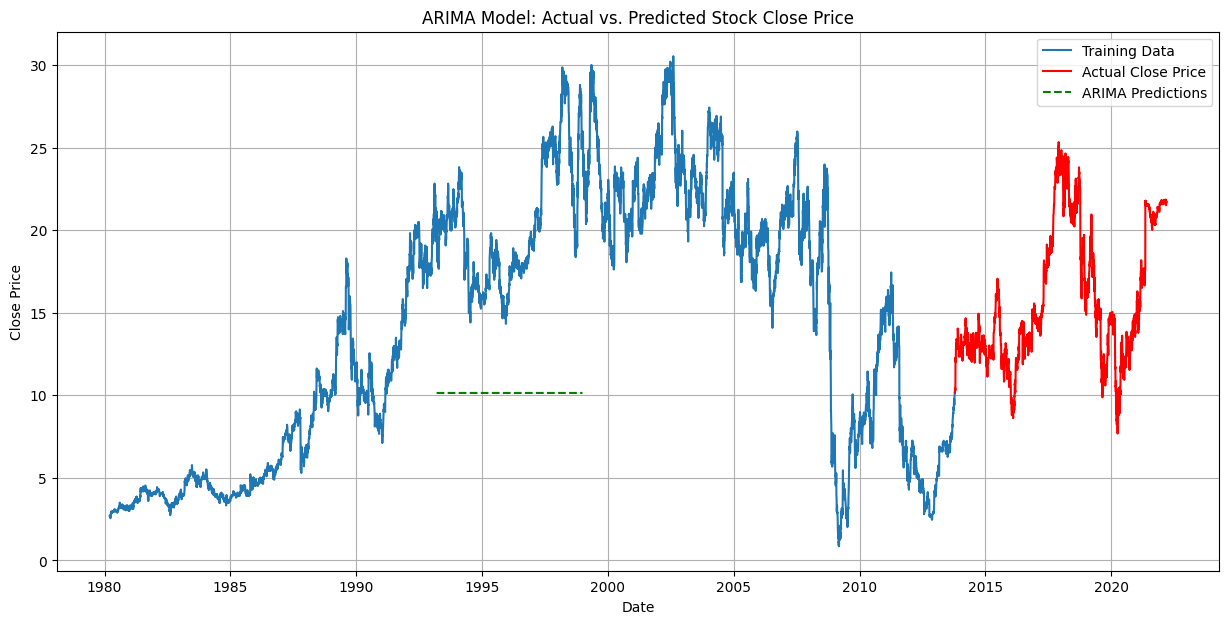

Actual vs. Predicted plot displayed.


In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 7))
plt.plot(train_data.index, train_data, label='Training Data')
plt.plot(test_data.index, test_data, label='Actual Close Price', color='red')
plt.plot(predictions.index, predictions, label='ARIMA Predictions', color='green', linestyle='--')
plt.title('ARIMA Model: Actual vs. Predicted Stock Close Price')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.show()

print("Actual vs. Predicted plot displayed.")

**Summary:**
   **Insights from Decomposition**: The time series decomposition using an additive model revealed a clear trend, seasonality (yearly, with a period of 365 days), and residual components in the stock's closing prices. This indicated that the stock price has predictable patterns over time.
   **Performance of Smoothing Techniques**: Both the 30-day Simple Moving Average (SMA) and Exponential Moving Average (EMA) successfully smoothed out the short-term fluctuations in the stock's closing price. EMA generally reacts faster to recent price changes compared to SMA, providing a smoother yet responsive trend indicator.
   **Accuracy of the ARIMA/SARIMA Model's Forecast**: The ARIMA(1,1,1) model achieved a Root Mean Squared Error (RMSE) of 6.926 and a Mean Squared Error (MSE) of 47.963 on the test set. While the model provided a reasonable forecast, visual inspection showed it captured the general trend but struggled to predict sharp short-term movements, indicating potential for improvement in capturing volatility.

### Data Analysis Key Findings
*   The stock's closing price time series exhibited a discernible trend and yearly seasonality, along with irregular residual components.
*   The original time series was found to be non-stationary (p-value of ADF test = 0.153196). After first-order differencing, the series became stationary (p-value of ADF test = 0.000000).
*   A 30-day Simple Moving Average (SMA) and Exponential Moving Average (EMA) were applied, successfully smoothing the price data and making underlying trends more apparent. EMA showed quicker responsiveness to recent price changes than SMA.
*   An ARIMA(1,1,1) model was developed based on stationarity tests and ACF/PACF analysis.
*   The ARIMA model's forecast for the test set resulted in a Mean Squared Error (MSE) of 47.963 and a Root Mean Squared Error (RMSE) of 6.926.
*   Visual comparison of actual vs. predicted values showed that the ARIMA model generally followed the long-term trend but diverged from actual prices during periods of high volatility.

**Insights or Next Steps**
*   **Explore SARIMA or more complex models**: Given the identified yearly seasonality, a SARIMA model (Seasonal ARIMA) could potentially capture the seasonal component more effectively than a non-seasonal ARIMA, leading to improved forecast accuracy. # looking forward to exploring with a SARIMA model
*   **Incorporate external factors**: Consider integrating macroeconomic indicators, company news, or market sentiment data into the forecasting model to potentially enhance predictive power, especially for capturing sudden price movements not explained by historical price patterns alone.
